In [50]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [6]:
df = pd.read_csv('D:/Downloads/Telegram Desktop/telecom_churn (2).csv')
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

Пропусков нет

2 категориальных столбца: state, area code

3 булевых столбцов: churn, voice mail plan, international plan

Cтолбец phone number как id

Все остальные столбцы числовые

In [20]:
df['churn'].value_counts()

churn
False    2850
True      483
Name: count, dtype: int64

In [21]:
X = df.drop('churn', axis=1)
y = df['churn']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=67, stratify=y)

In [37]:
categorical_cols = ['state', 'area code']
numerical_cols = X_train.select_dtypes(include=['int64', 'float64', 'bool']).columns.drop(['area code'])

encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat  = encoder.transform(X_test[categorical_cols])

scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numerical_cols])
X_test_num  = scaler.transform(X_test[numerical_cols])

X_train_processed = pd.concat([
    pd.DataFrame(X_train_num, columns=numerical_cols, index=X_train.index),
    pd.DataFrame(X_train_cat, columns=encoder.get_feature_names_out(categorical_cols), index=X_train.index)
], axis=1)

X_test_processed = pd.concat([
    pd.DataFrame(X_test_num,  columns=numerical_cols, index=X_test.index),
    pd.DataFrame(X_test_cat,  columns=encoder.get_feature_names_out(categorical_cols), index=X_test.index)
], axis=1)

C:\Users\Ivan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [41]:
logreg = LogisticRegression(max_iter=1000, random_state=67, n_jobs=-1)
dtree = DecisionTreeClassifier(max_depth=8, random_state=67)
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
logreg.fit(X_train_processed, y_train)
dtree.fit(X_train_processed, y_train)
knn.fit(X_train_processed, y_train)

KNeighborsClassifier(n_jobs=-1)

In [48]:
y_pred_logreg = logreg.predict(X_test_processed)
y_pred_tree = dtree.predict(X_test_processed)
y_pred_knn = knn.predict(X_test_processed)

acc_logreg = accuracy_score(y_test, y_pred_logreg)
acc_tree = accuracy_score(y_test, y_pred_tree)
acc_knn = accuracy_score(y_test, y_pred_knn)

print(f'Logistic Regression Accuracy: {acc_logreg:.4f}')
print(f'Decision Tree Accuracy: {acc_tree:.4f}')
print(f'KNN Accuracy: {acc_knn:.4f}')

Logistic Regression Accuracy: 0.8525
Decision Tree Accuracy: 0.9065
KNN Accuracy: 0.8837


C:\Users\Ivan\AppData\Local\Temp\ipykernel_20072\543282640.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette='mako')


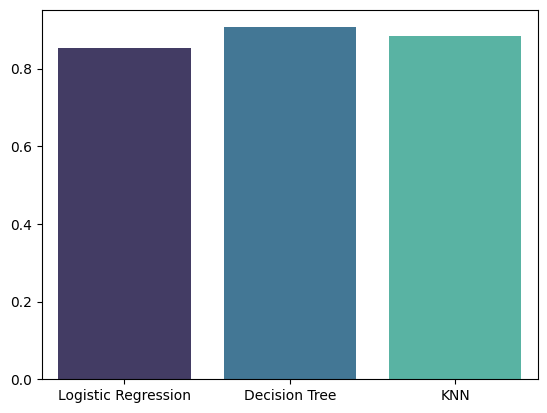

In [ ]:
results = {'Logistic Regression': acc_logreg, 'Decision Tree': acc_tree, 'KNN': acc_knn}
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='mako')
plt.show()

Лучший результат показала модель Decision Tree

In [51]:
cm = confusion_matrix(y_test, y_pred_tree)
print(cm)

[[693  20]
 [ 58  63]]


Модель ошибочно предсказала как ушедших (False Positive) 20 клиентов

Модель ошибочно предсказала как лояльных (остануться) 58 клиентов